<a href="https://colab.research.google.com/github/Cristiand056/practicas_IA/blob/main/Breats_cancer_with_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("obulisainaren/multi-cancer")

print("Path to dataset files:", path)

100%|██████████| 8.62G/8.62G [01:24<00:00, 109MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3


In [ ]:
import os


In [ ]:
path_breats_cancer = "/root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/Breast Cancer"

In [ ]:
total_images = 0
subclasses = [d for d in os.listdir(path_breats_cancer) if os.path.isdir(os.path.join(path_breats_cancer, d))]
print("Subclases (si hay):", subclasses)

Subclases (si hay): ['breast_malignant', 'breast_benign']


In [ ]:
if subclasses:
    for sub in subclasses:
        sub_path = os.path.join(path_breats_cancer, sub)
        num_imgs = len([f for f in os.listdir(sub_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        print(f"{sub}: {num_imgs} imágenes")
        total_images += num_imgs
else:
    num_imgs = len([f for f in os.listdir(path_breats_cancer) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    print(f"Imágenes directas: {num_imgs}")
    total_images = num_imgs

print(f"Total de imágenes de cáncer de seno: {total_images}")

breast_malignant: 5000 imágenes
breast_benign: 5000 imágenes
Total de imágenes de cáncer de seno: 10000


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def show_samples(path, num_samples=5):
    image_files = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))][:num_samples]
    if not image_files:
        print("No hay imágenes en esta carpeta.")
        return

    fig, axes = plt.subplots(1, len(image_files), figsize=(15, 3))
    axes = axes if len(image_files) > 1 else [axes]
    for i, ax in enumerate(axes):
        img_path = os.path.join(path, image_files[i])
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(image_files[i][:15])  # Título corto
    plt.show()


Mostrando muestras de: breast_malignant


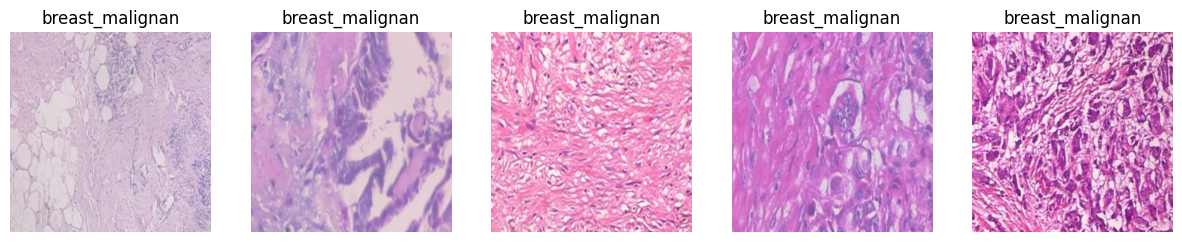

In [ ]:
if subclasses:
    sample_sub_path = os.path.join(path_breats_cancer, subclasses[0])
    print(f"Mostrando muestras de: {subclasses[0]}")
    show_samples(sample_sub_path)
else:
    print("Mostrando muestras directas:")
    show_samples(path_breats_cancer)

Mostrando muestras de: breast_benign


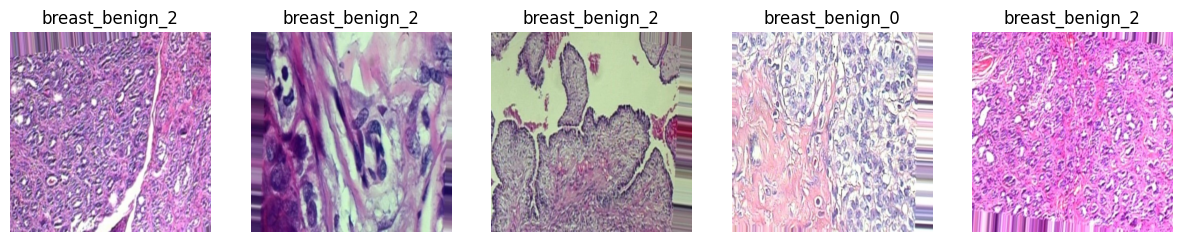

In [ ]:
if subclasses:
    sample_sub_path = os.path.join(path_breats_cancer, subclasses[1])
    print(f"Mostrando muestras de: {subclasses[1]}")
    show_samples(sample_sub_path)
else:
    print("Mostrando muestras directas:")
    show_samples(path_breats_cancer)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    path_breats_cancer,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical' if len(subclasses) > 1 else 'binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    path_breats_cancer,
    target_size=(224, 224),
    #bacth_size=32,
    class_mode='categorical' if len(subclasses) > 1 else 'binary',
    subset='validation'
)

print("Clases detectadas:", train_gen.class_indices)

Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Clases detectadas: {'breast_benign': 0, 'breast_malignant': 1}


In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Input(shape=(224, 224, 3)))

model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(subclasses), activation='softmax'))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,650 (91.20 MB)

 Trainable params: 23,907,650 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'recall'])
model.fit(train_gen, epochs=10, batch_size=32, validation_data=val_gen, verbose=1)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8899 - loss: 0.3104 - recall: 0.8899

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


250/250 ━━━━━━━━━━━━━━━━━━━━ 802s 3s/step - accuracy: 0.8899 - loss: 0.3104 - recall: 0.8899 - val_accuracy: 0.8890 - val_loss: 0.2945 - val_recall: 0.8890
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 797s 3s/step - accuracy: 0.9166 - loss: 0.2201 - recall: 0.9166 - val_accuracy: 0.8980 - val_loss: 0.2338 - val_recall: 0.8980
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 804s 3s/step - accuracy: 0.9267 - loss: 0.1971 - recall: 0.9267 - val_accuracy: 0.9045 - val_loss: 0.2486 - val_recall: 0.9045
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 809s 3s/step - accuracy: 0.9541 - loss: 0.1343 - recall: 0.9541 - val_accuracy: 0.8990 - val_loss: 0.3946 - val_recall: 0.8990
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 801s 3s/step - accuracy: 0.9599 - loss: 0.1178 - recall: 0.9599 - val_accuracy: 0.9065 - val_loss: 0.3305 - val_recall: 0.9065
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 811s 3s/step - accuracy: 0.9716 - loss: 0.0819 - recall: 0.9716 - val_accuracy: 0.9190 - val_loss: 0.3010 - val_recall: 0.9190
Epoch 7/1

In [47]:
y_perdict = model.predict(val_gen)

63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 971ms/step
